In [ ]:
# ==========================================
# NEXT CYCLE LENGTH PREDICTION: LEAKAGE-AWARE EVALUATION
# ==========================================
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import GroupKFold

warnings.simplefilter(action="ignore", category=FutureWarning)

RANDOM_STATE = 42
MIN_CYCLE_LEN = 21
MAX_CYCLE_LEN = 38
N_SPLITS = 5

# Find the supplied dataset folder whether this notebook is opened from the repo or workspace root.
data_dir = next(
    (
        parent / "Dataset for Models" / "for period detection"
        for parent in (Path.cwd(), *Path.cwd().parents)
        if (parent / "Dataset for Models" / "for period detection" / "hormones_and_selfreport.csv").exists()
    ),
    None,
)
if data_dir is None:
    raise FileNotFoundError("Could not locate Dataset for Models/for period detection from the current directory or its parents.")

hormones = pd.read_csv(data_dir / "hormones_and_selfreport.csv")
sleep = pd.read_csv(data_dir / "sleep.csv")
stress = pd.read_csv(data_dir / "stress_score.csv")
exercise = pd.read_csv(data_dir / "exercise.csv")
body = pd.read_csv(data_dir / "height_and_weight.csv")
subject_info = pd.read_csv(data_dir / "subject-info.csv")


def is_period_flow(value):
    if pd.isna(value):
        return False
    return str(value).strip().lower() not in {"", "not at all", "none", "no", "0", "0.0", "nan"}


def calc_bmi(row):
    height = row.get("height_2024") if pd.notna(row.get("height_2024")) else row.get("height_2022")
    weight = row.get("weight_2024") if pd.notna(row.get("weight_2024")) else row.get("weight_2022")
    if pd.notna(height) and pd.notna(weight) and float(height) > 0:
        return float(weight) / ((float(height) / 100.0) ** 2)
    return np.nan


body["bmi"] = body.apply(calc_bmi, axis=1)
bmi_dict = body.set_index("id")["bmi"].to_dict()
birth_year_dict = subject_info.set_index("id")["birth_year"].to_dict()
menarche_dict = subject_info.set_index("id")["age_of_first_menarche"].to_dict()

sleep_daily = (
    sleep.groupby(["id", "sleep_start_day_in_study"])["efficiency"]
    .mean()
    .reset_index()
    .rename(columns={"sleep_start_day_in_study": "day_in_study"})
)
valid_stress = stress[stress["stress_score"] > 0].copy()
stress_daily = valid_stress.groupby(["id", "day_in_study"])["stress_score"].mean().reset_index()
exercise_daily = (
    exercise.groupby(["id", "start_day_in_study"])["calories"]
    .sum()
    .reset_index()
    .rename(columns={"start_day_in_study": "day_in_study"})
)

daily_df = (
    hormones.merge(sleep_daily, on=["id", "day_in_study"], how="left")
    .merge(stress_daily, on=["id", "day_in_study"], how="left")
    .merge(exercise_daily, on=["id", "day_in_study"], how="left")
)
daily_df["calories"] = daily_df["calories"].fillna(0.0)

symptom_map = {
    "Not at all": 0,
    "Very Low/Little": 1,
    "Low": 2,
    "Moderate": 3,
    "High": 4,
    "Very High": 5,
}
symptom_cols = ["cramps", "sorebreasts", "fatigue", "moodswing"]
for column in symptom_cols:
    daily_df[column] = pd.to_numeric(daily_df[column].map(symptom_map), errors="coerce")

# Build each row from the completed preceding cycle only. Missing values remain missing
# until fold-specific imputation, avoiding full-dataset and future-record imputation.
rows = []
for user_id, group in daily_df.groupby("id"):
    group = group.sort_values("day_in_study").copy()
    is_period = group["flow_volume"].apply(is_period_flow)
    previous_is_period = is_period.shift(1, fill_value=False)
    period_starts = group.loc[is_period & ~previous_is_period, "day_in_study"].to_numpy()
    if len(period_starts) < 3:
        continue

    cycle_lengths = np.diff(period_starts)
    for index in range(1, len(period_starts) - 1):
        target_len = int(cycle_lengths[index])
        previous_len = int(cycle_lengths[index - 1])
        if not (
            MIN_CYCLE_LEN <= target_len <= MAX_CYCLE_LEN
            and MIN_CYCLE_LEN <= previous_len <= MAX_CYCLE_LEN
        ):
            continue

        previous_start = period_starts[index - 1]
        current_start = period_starts[index]
        previous_cycle = group[
            (group["day_in_study"] >= previous_start)
            & (group["day_in_study"] < current_start)
        ]
        past_cycle_lengths = cycle_lengths[max(0, index - 3):index]
        birth_year = birth_year_dict.get(user_id, np.nan)

        rows.append({
            "id": user_id,
            "prev_cycle_len": float(previous_len),
            "avg_3_cycles": float(np.mean(past_cycle_lengths)) if len(past_cycle_lengths) else float(previous_len),
            "prev_avg_stress": previous_cycle["stress_score"].mean(),
            "prev_avg_sleep": previous_cycle["efficiency"].mean(),
            "prev_total_cals": previous_cycle["calories"].sum(min_count=1),
            "prev_avg_cramps": previous_cycle["cramps"].mean(),
            "prev_avg_sorebreasts": previous_cycle["sorebreasts"].mean(),
            "prev_avg_fatigue": previous_cycle["fatigue"].mean(),
            "prev_avg_moodswing": previous_cycle["moodswing"].mean(),
            "bmi": bmi_dict.get(user_id, np.nan),
            "age": 2024 - birth_year if pd.notna(birth_year) else np.nan,
            "menarche_age": menarche_dict.get(user_id, np.nan),
            "t_next_period": float(target_len),
        })

df_train = pd.DataFrame(rows)
print(f"Dataset: {data_dir}")
print(f"Eligible cycle observations: {len(df_train)}")
print(f"Participants contributing eligible observations: {df_train['id'].nunique()}")

features = [
    "prev_cycle_len", "avg_3_cycles",
    "prev_avg_stress", "prev_avg_sleep", "prev_total_cals",
    "prev_avg_cramps", "prev_avg_sorebreasts", "prev_avg_fatigue", "prev_avg_moodswing",
    "bmi", "age", "menarche_age",
]
target = "t_next_period"
X = df_train[features]
y = df_train[target]
groups = df_train["id"]
if groups.nunique() < N_SPLITS:
    raise ValueError(f"Need at least {N_SPLITS} participant groups; found {groups.nunique()}.")
gkf = GroupKFold(n_splits=N_SPLITS)

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        max_depth=3,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Linear Regression": LinearRegression(),
}
method_predictions = {name: np.full(len(y), np.nan) for name in [*models, "Previous cycle", "Previous 3-cycle average"]}
fold_rows = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    imputer = SimpleImputer(strategy="mean", keep_empty_features=True)
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)

    predictions_by_method = {
        "Previous cycle": X_test["prev_cycle_len"].to_numpy(dtype=float),
        "Previous 3-cycle average": X_test["avg_3_cycles"].to_numpy(dtype=float),
    }
    for name, estimator in models.items():
        estimator.fit(X_train_imputed, y_train)
        predictions_by_method[name] = estimator.predict(X_test_imputed)

    for method, predictions in predictions_by_method.items():
        method_predictions[method][test_idx] = predictions
        fold_rows.append({
            "fold": fold,
            "method": method,
            "test_cycles": len(test_idx),
            "test_participants": groups.iloc[test_idx].nunique(),
            "MAE": mean_absolute_error(y_test, predictions),
            "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
            "MAPE_percent": mean_absolute_percentage_error(y_test, predictions) * 100,
            "R2": r2_score(y_test, predictions) if len(test_idx) >= 2 else np.nan,
        })

fold_results = pd.DataFrame(fold_rows)
metric_columns = ["MAE", "RMSE", "MAPE_percent", "R2"]
summary_rows = []
for method, predictions in method_predictions.items():
    method_folds = fold_results[fold_results["method"] == method]
    summary = {"method": method}
    for metric in metric_columns:
        values = method_folds[metric].dropna()
        summary[f"{metric}_mean"] = values.mean()
        summary[f"{metric}_SD"] = values.std(ddof=1)
    summary["pooled_MAE"] = mean_absolute_error(y, predictions)
    summary["pooled_RMSE"] = np.sqrt(mean_squared_error(y, predictions))
    summary["pooled_MAPE_percent"] = mean_absolute_percentage_error(y, predictions) * 100
    summary["pooled_R2"] = r2_score(y, predictions)
    summary_rows.append(summary)

summary_results = pd.DataFrame(summary_rows)
print("\nFold-level metrics:")
print(fold_results.to_string(index=False, float_format=lambda value: f"{value:.3f}"))
print("\nMean ± sample SD across folds; pooled out-of-fold metrics shown separately:")
print(summary_results.to_string(index=False, float_format=lambda value: f"{value:.3f}"))

rf_predictions = method_predictions["Random Forest"]
absolute_errors = np.abs(y.to_numpy() - rf_predictions)
print("\nRandom Forest pooled out-of-fold absolute-error windows:")
for threshold in (2, 3, 5):
    count = int(np.sum(absolute_errors <= threshold))
    print(f"Within ±{threshold} days: {count}/{len(y)} ({100 * count / len(y):.1f}%)")

# Refit the production estimator on all eligible rows after evaluation.
final_imputer = SimpleImputer(strategy="mean", keep_empty_features=True)
X_imputed_full = final_imputer.fit_transform(X)
final_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=3,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
final_model.fit(X_imputed_full, y)
bundle = {"model": final_model, "features": features, "imputer": final_imputer}

# Save to a distinct evaluation artifact; this does not overwrite the service bundle.
evaluation_bundle_path = Path.cwd() / "next_period_predictor_bundle_evaluated.pkl"
joblib.dump(bundle, evaluation_bundle_path)
print(f"\nSaved final refit evaluation artifact: {evaluation_bundle_path}")

1) Loading Data Files...
2) Aggregating daily logs...
3) Extracting cycles for NEXT PERIOD prediction...
-> Extracted 20 valid cycles.
4) Evaluating Hybrid ML Engine with Cross-Validation...

        MODEL RELIABILITY REPORT (CROSS-VALIDATED)
🔹 Mean Absolute Error (MAE):  +/- 1.98 days
🔹 Root Mean Squared Error (RMSE): 2.69 days
🔹 Mean Absolute Percentage Error (MAPE): 7.16%
🔹 R² Score (Hybrid System): 0.070
--------------------------------------------------
🎯 CLINICAL ACCURACY SCORES:
   Predictions within ±2 days: 60.0%
   Predictions within ±3 days: 70.0%
   Predictions within ±5 days: 95.0%

💾 Saved as: next_period_predictor_bundle.pkl


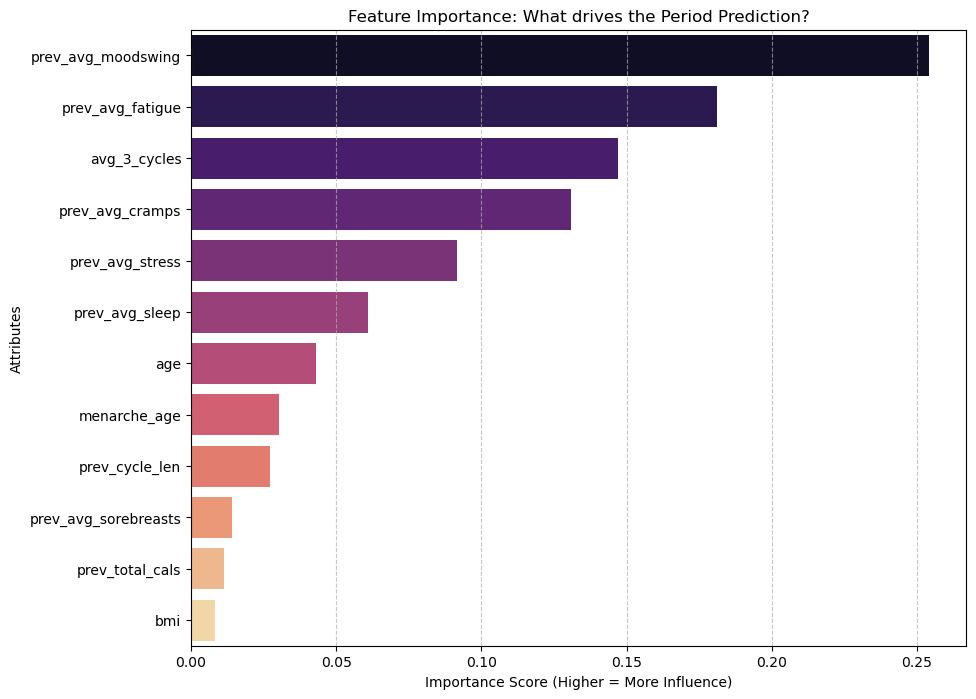

Top 5 Drivers of your Model:
              Feature  Importance
8  prev_avg_moodswing    0.254224
7    prev_avg_fatigue    0.181149
1        avg_3_cycles    0.146981
5     prev_avg_cramps    0.130710
2     prev_avg_stress    0.091499


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract importance from your trained model
importances = bundle["model"].feature_importances_
feature_names = bundle["features"]

# 2. Create a DataFrame for visualization
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the results
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='magma')
plt.title('Feature Importance: What drives the Period Prediction?')
plt.xlabel('Importance Score (Higher = More Influence)')
plt.ylabel('Attributes')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Print the top 5 most important features
print("Top 5 Drivers of your Model:")
print(fi_df.head(5))

In [3]:
# Check how many people actually logged symptoms
print(df_train[['prev_avg_cramps', 'prev_avg_moodswing']].describe())

       prev_avg_cramps  prev_avg_moodswing
count        20.000000           20.000000
mean          0.913538            1.554037
std           0.760689            0.973933
min           0.132698            0.045455
25%           0.409344            0.762360
50%           0.708775            1.637408
75%           1.296237            2.195341
max           3.407407            3.028736
